# Impact of Effects of Site in Machine Learning Pipelines
---
The effects of site (EoS) can have two opposite effects on Machine Learning (ML) pipelines.

- They can **hinder** the real signal. In these cases, the ML models will have a harder time finding the true signal, thus removing EoS should **improve** our classification, as the signal-to-noise ratio should improve.

- They can **confound** the real signal. In these cases, the ML model can **use** the EoS signal to *fraudulently* improve the performance, as the predictions will not be based on a true biological signal but rather on site effects. In such cases, removing the EoS should *reduce* the model's performance. In general, this scenario happens when there is a class imbalance across sites, for example, because all (or the majority) of our patients came from one site and all (or the majority) of our controls came from another site.

In real-world scenarios, we will have a mix of both effects, which makes the EoS particularly difficult to diagnose.

In these exercises, we will play with this 3 main factors, aiming to showcase the impact of these factors in the ML pipelines:

- Real signal strength.
- Effect of site strength.
- Class imbalance across sites.

In [1]:
# Imports
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

from uniharmony import verbosity
from uniharmony.datasets import make_multisite_classification
from uniharmony.plot import plot_decision_boundary_2d

# Set uniharmony verbosity to warnings to avoid unnecessary messages.
verbosity("warning")

sns.set_theme(style="whitegrid")

# For all our experiments, we will use LogisticRegression as classification model.
clf = LogisticRegression()
# For reproducibility
random_state = 42
# For all our experiments, we will use a Stratified K-fold with 10 folds.
# The stratification makes all classes (target) equally represented in all our folds.
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)

## Section 1: Creating a Baseline

### First, lets create an example without EoS and without class imbalance across site.

We will use this performance as baseline to compare the rest of the simulated scenarios.

Problem characteristic:
- Real signal: Yes
- Effect of site: No
- Class imbalance: No

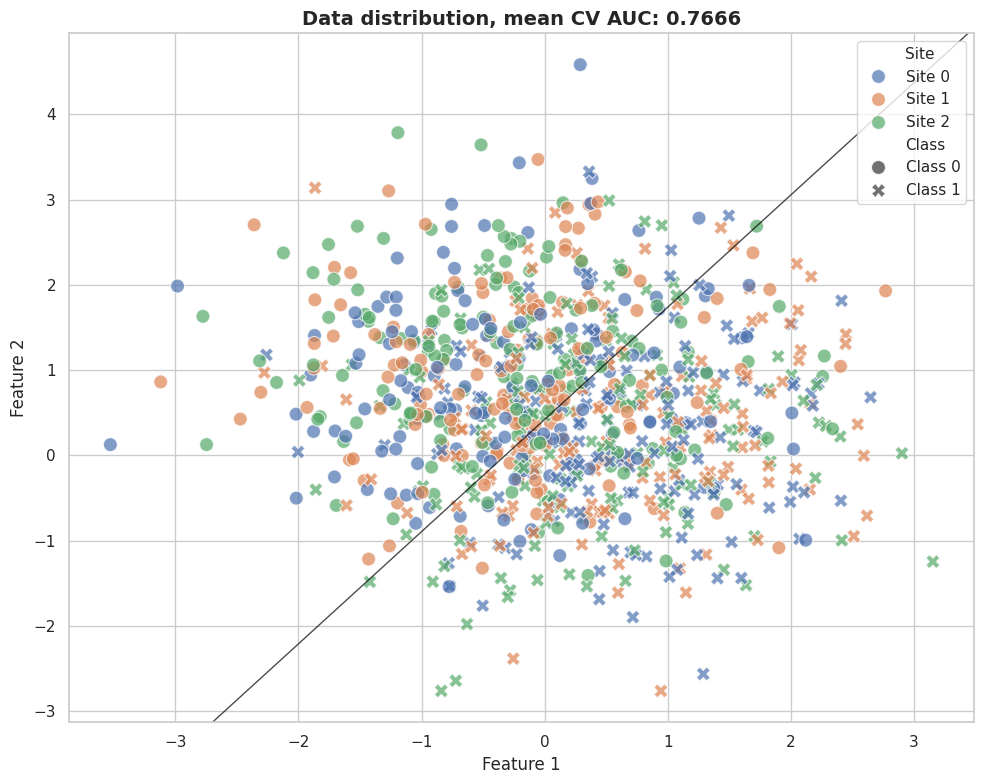

In [2]:
# Data generation
# ---------------
X, y, sites = make_multisite_classification(
    n_samples=900,
    n_sites=3,
    n_features=2,
    signal_strength=1,
    site_effect_strength=0,
    balance_per_site=[0.5, 0.5, 0.5],
    signal_type="blobs",
    random_state=random_state,
)
# Create DataFrame for easier plotting
df = pd.DataFrame(
    {
        "Feature 1": X[:, 0],
        "Feature 2": X[:, 1],
        "Class": [f"Class {c}" for c in y],
        "Site": [f"Site {s}" for s in sites],
    }
)
# This is the ML step
# Perform 10-fold stratified cross-validation
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot with site as hue and class as style
sns.scatterplot(
    data=df,
    x="Feature 1",
    y="Feature 2",
    hue="Site",
    style="Class",
    s=100,
    alpha=0.7,
    ax=ax,
    hue_order=["Site 0", "Site 1", "Site 2"],
    style_order=["Class 0", "Class 1"],
)
ax.set_title(
    f"Data distribution, mean CV AUC: {scores.mean():.4f}",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()

# Fit the model and plot the decision boundary,
# this is just for visualization purposes, the real evaluation was be done with cross-validation
clf.fit(X, y)
plot_decision_boundary_2d(ax, clf)

### As no EoS is presented, the sites are indistinguishable from each other.

---

## Section 2: Adding EoS.

### Now, let's add an EoS. For simplicity, let's add a simple location effect. Let's maintain our class balance across the site.

Problem characteristic:
- Real signal: Yes
- Effect of site: Yes
- Class imbalance: No

What to expect?

- On the features, we will expect that our sites will start being easier to separate, as each feature will be affected differently depending on the site.
- On the ML performance, we will expect a drop in performance with respect to our baseline, as now the EoS are not confounded with the classes, as the classes are balanced. The EoS will act as noise.

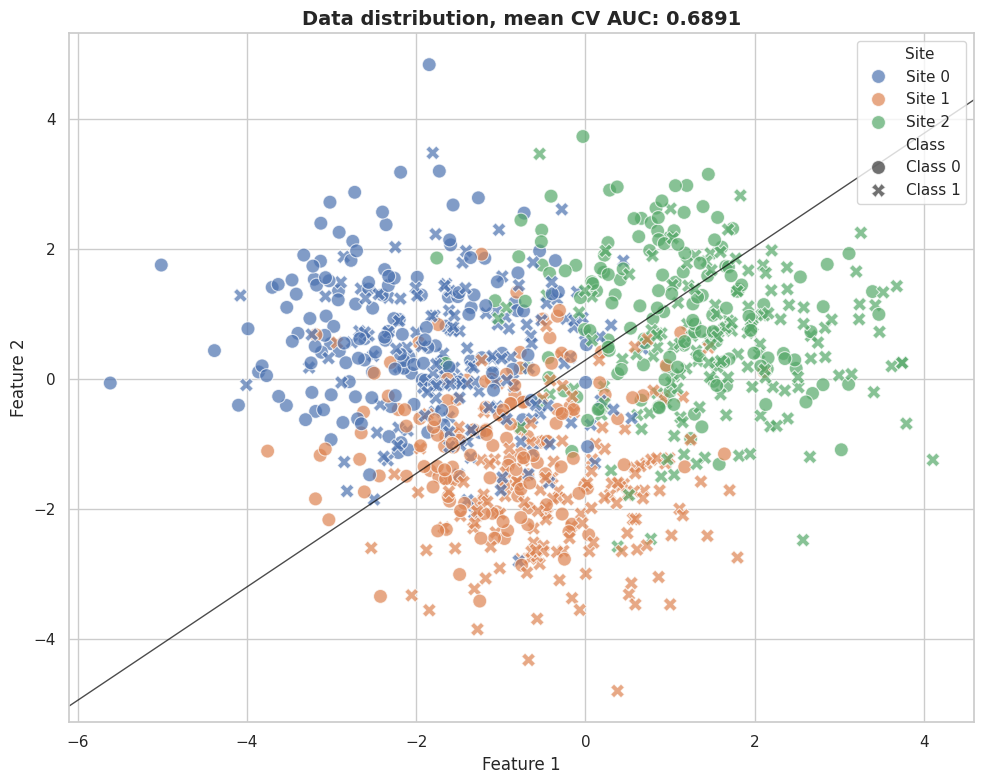

In [3]:
X, y, sites = make_multisite_classification(
    n_samples=900,
    n_sites=3,
    n_features=2,
    signal_strength=1,
    site_effect_strength=1,
    balance_per_site=[0.5, 0.5, 0.5],
    site_effect_type="location",
    site_effect_homogeneous=False,  # Make each feature to be affected differently. If True, the same EoS is apply to all features in the same site.
    signal_type="blobs",
    random_state=random_state,
)
# Create DataFrame for easier plotting
df = pd.DataFrame(
    {
        "Feature 1": X[:, 0],
        "Feature 2": X[:, 1],
        "Class": [f"Class {c}" for c in y],
        "Site": [f"Site {s}" for s in sites],
    }
)
# Perform 10-fold stratified cross-validation
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
# Plot with site as hue and class as style
sns.scatterplot(
    data=df,
    x="Feature 1",
    y="Feature 2",
    hue="Site",
    style="Class",
    s=100,
    alpha=0.7,
    ax=ax,
    hue_order=["Site 0", "Site 1", "Site 2"],
    style_order=["Class 0", "Class 1"],
)
ax.set_title(
    f"Data distribution, mean CV AUC: {scores.mean():.4f}",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()

# Fit the model and plot the decision boundary,
# this is just for visualization purposes, the real evaluation was be done with cross-validation
clf.fit(X, y)
plot_decision_boundary_2d(ax, clf)

### Now the sites (colors) are easier to distinguish. Each feature is affected differently in each site.

### Exercise

Change the value of the effect of site to check how the model behaves in more extreme cases.

### Solution

You can check the solution [here](https://github.com/N-Nieto/OHBM2026_Educational_course_harmonization/tree/main/solutions/block03)


---

## Section 3. Add class imbalance.

### Now, Let's change the class balance in our sites.

Problem characteristic:
- Real signal: Yes
- Effect of site: Yes
- Class imbalance: Yes

What to expect?

- On the features, we will expect that our sites will start being easier to separate, as each feature will be affected differently depending on the site.
- On the ML performance, we will expect a drop in performance with respect to our (baseline) 

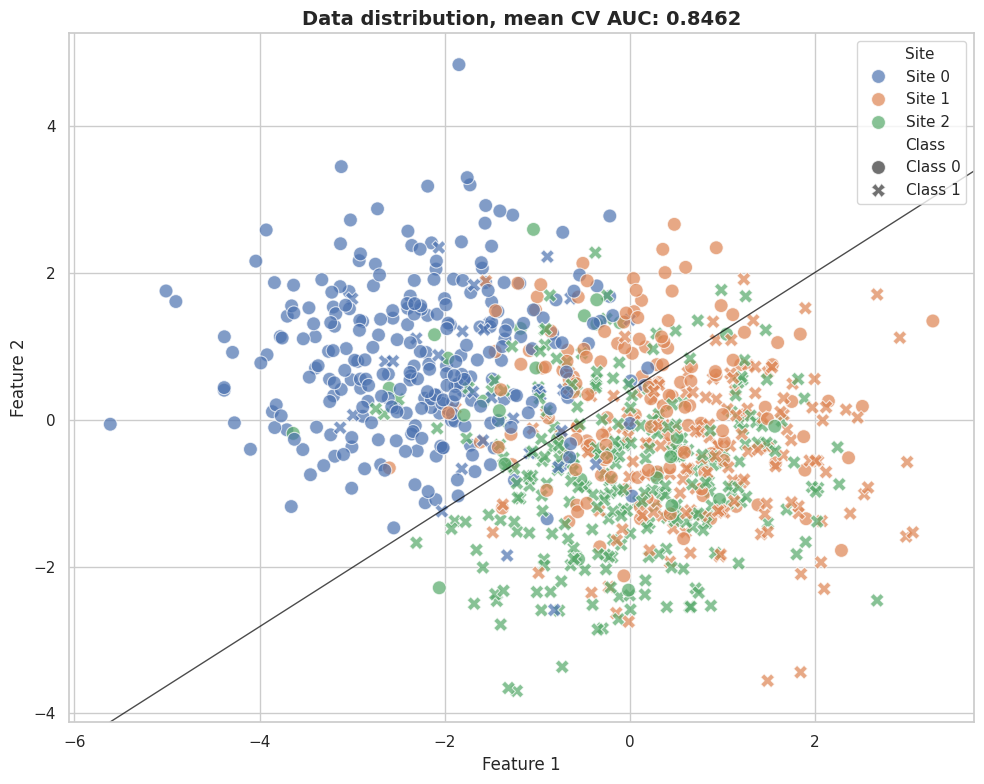

In [4]:
# Here, we can provide how is the imbalance of class 1 for each site.
# In this case, only a 10% of class 1 will be presented in site 1, while 90% of samples will come for class 1 in site 3. Site 2 is still balanced.
balance_per_site = [0.1, 0.5, 0.9]

X, y, sites = make_multisite_classification(
    n_samples=900,
    n_sites=3,
    n_features=2,
    signal_strength=1,
    site_effect_strength=1,
    balance_per_site=balance_per_site,
    signal_type="blobs",
    site_effect_homogeneous=False,
    site_effect_type="location",
    random_state=random_state,
)
# Create DataFrame for easier plotting
df = pd.DataFrame(
    {
        "Feature 1": X[:, 0],
        "Feature 2": X[:, 1],
        "Class": [f"Class {c}" for c in y],
        "Site": [f"Site {s}" for s in sites],
    }
)
# Perform 10-fold stratified cross-validation
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
# Plot with site as hue and class as style
sns.scatterplot(
    data=df,
    x="Feature 1",
    y="Feature 2",
    hue="Site",
    style="Class",
    s=100,
    alpha=0.7,
    ax=ax,
    hue_order=["Site 0", "Site 1", "Site 2"],
    style_order=["Class 0", "Class 1"],
)
ax.set_title(
    f"Data distribution, mean CV AUC: {scores.mean():.4f}",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()

# Fit the model and plot the decision boundary,
# this is just for visualization purposes, the real evaluation was be done with cross-validation
clf.fit(X, y)
plot_decision_boundary_2d(ax, clf)

### Now, Site 0 (blue color) has more data from Class 0 (circles) (90%), as we set the amount of Class 1 to be 10%. 

---

## Section 3: Removing Real signal

### Let's remove the real signal.

Problem characteristic:
- Real signal: No
- Effect of site: Yes
- Class imbalance: Yes

What to expect?

- While our ML model should give a by chance performance, as no real signal is presented, the ML model, we will pick the EoS as real signal, as now those are confounded. 

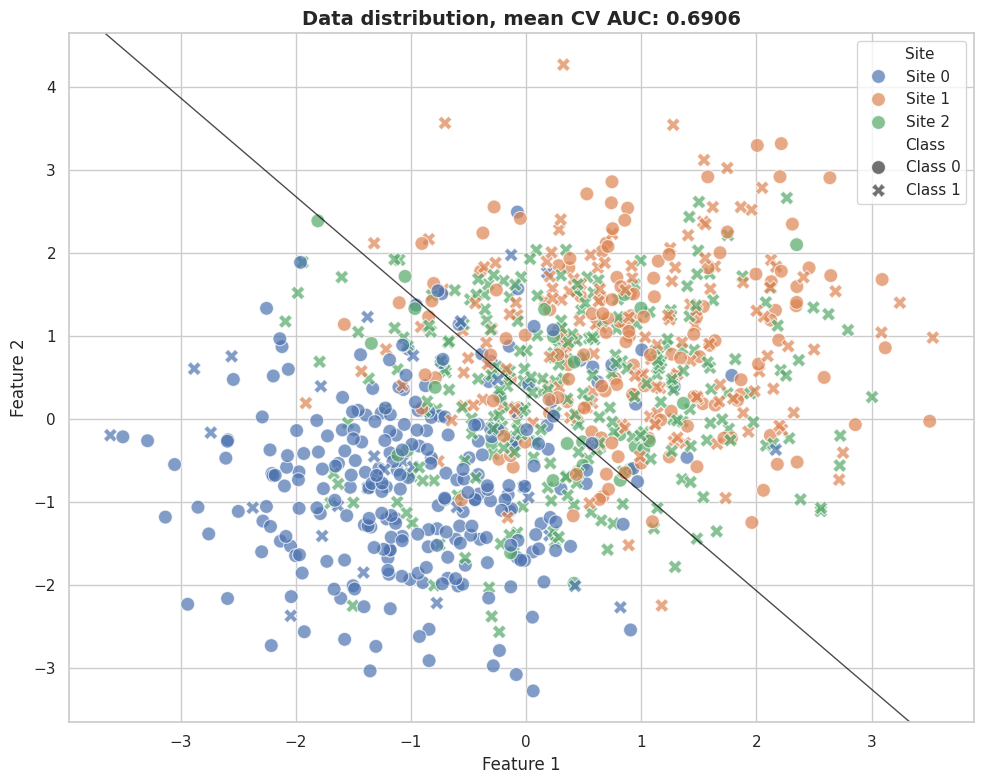

In [5]:
X, y, sites = make_multisite_classification(
    n_samples=900,
    n_sites=3,
    n_features=2,
    signal_strength=0.01,
    site_effect_strength=1,
    site_effect_type="location",
    signal_type="blobs",
    random_state=23,
    balance_per_site=[0.1, 0.5, 0.9],
)
# Create DataFrame for easier plotting
df = pd.DataFrame(
    {
        "Feature 1": X[:, 0],
        "Feature 2": X[:, 1],
        "Class": [f"Class {c}" for c in y],
        "Site": [f"Site {s}" for s in sites],
    }
)
# Perform 10-fold stratified cross-validation
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
# Plot with site as hue and class as style
sns.scatterplot(
    data=df,
    x="Feature 1",
    y="Feature 2",
    hue="Site",
    style="Class",
    s=100,
    alpha=0.7,
    ax=ax,
    hue_order=["Site 0", "Site 1", "Site 2"],
    style_order=["Class 0", "Class 1"],
)
ax.set_title(
    f"Data distribution, mean CV AUC: {scores.mean():.4f}",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()

# Fit the model and plot the decision boundary,
# this is just for visualization purposes, the real evaluation was be done with cross-validation
clf.fit(X, y)
plot_decision_boundary_2d(ax, clf)

### Even without any real signal, our model is obtaining a performance comparable with the baseline performance only using the EoS and the class imbalance!

---

## Section 4: Removing real an EoS signal.

### We now remove the real signal ant the EoS signal. Even with class imbalance across sites, there is nothing to pick up.

Problem characteristic:
- Real signal: No
- Effect of site: No
- Class imbalance: Yes

What to expect?

- As no signal is presented (nor real or EoS), the imbalance will not produce any effect in the classification performance.  

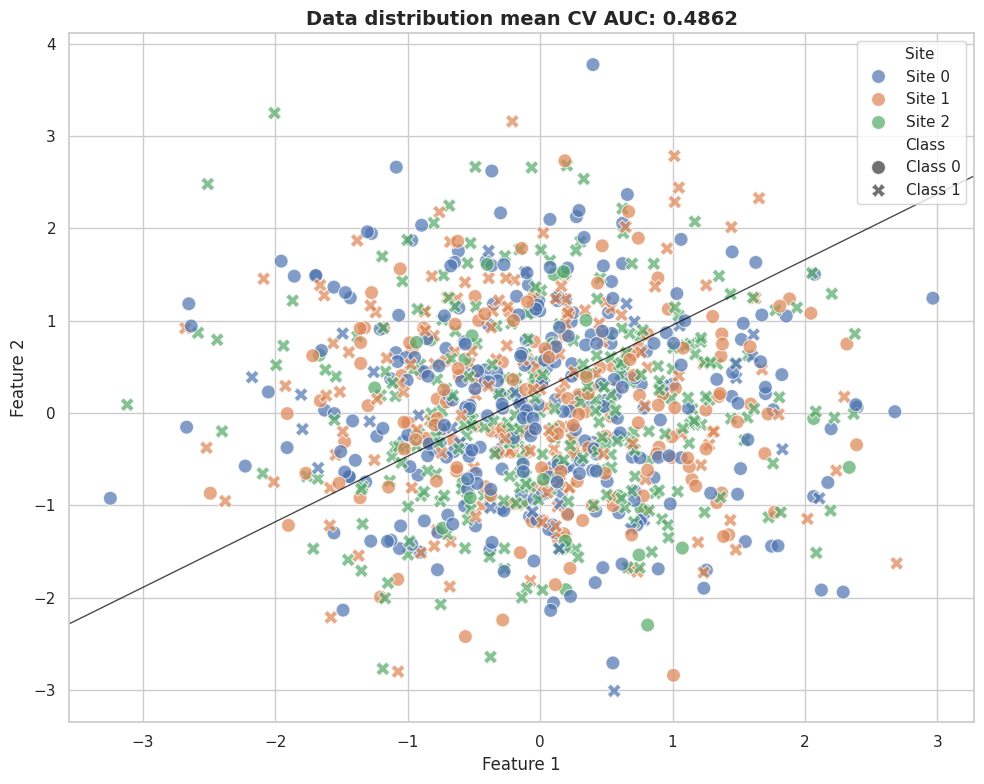

In [6]:
X, y, sites = make_multisite_classification(
    n_sites=3,
    n_features=2,
    signal_strength=0.01,
    site_effect_strength=0,
    signal_type="blobs",
    site_effect_homogeneous=False,
    balance_per_site=[0.1, 0.5, 0.9],
    random_state=random_state,
)

# Create DataFrame for easier plotting
df = pd.DataFrame(
    {
        "Feature 1": X[:, 0],
        "Feature 2": X[:, 1],
        "Class": [f"Class {c}" for c in y],
        "Site": [f"Site {s}" for s in sites],
    }
)
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
# Plot with site as hue and class as style
sns.scatterplot(
    data=df,
    x="Feature 1",
    y="Feature 2",
    hue="Site",
    style="Class",
    s=100,
    alpha=0.7,
    ax=ax,
    hue_order=["Site 0", "Site 1", "Site 2"],
    style_order=["Class 0", "Class 1"],
)

ax.set_title(
    f"Data distribution mean CV AUC: {scores.mean():.4f}",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()

# Fit the model and plot the decision boundary,
# this is just for visualization purposes, the real evaluation was be done with cross-validation
clf.fit(X, y)
plot_decision_boundary_2d(ax, clf)


## Take-away message.

- EoS can have a different effect in our ML analysis. A good first step is to check how the class imbalance is across sites.
- This example aims to showcase the basic possibilities. Real-world problems are much messier, with multiple sites, heterogeneous imbalances, more complex site-level effects, more features, and fewer subjects.

## Question
- After harmonizing our data, how could we distinguish if the harmonization model removed only the EoS signal, or it has only removed the real signal confounded with the sites?